In [1]:
#recap
import numpy as np

def compute_mse(y_actual, y_predicted):
  return np.mean((np.square(y_actual - y_predicted)))

In [2]:
y_actual = np.array([3, 5, 7, 9])
y_predicted = np.array([2, 5, 8, 9])

#built-in function
compute_mse(y_actual,y_predicted)

np.float64(0.5)

In [3]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_actual,y_predicted))

0.5


In [4]:
#The 3 steps of gradient descent as comments
  #step 1: calculate prediction
      #y_predicted = m*X + b
  #step 2: Calculate gradients for both -
      # 1. ∂MSE/∂m = (-2/n) × Σ x × (y_actual - y_predicted)
      #2. ∂MSE/∂b = (-2/n) × Σ (y_actual - y_predicted)
  #update rules
    # m = m - learning rate x  ∂MSE/∂m
    # b = b - learning rate x ∂MSE/∂b

In [5]:
# df.groupby('Pclass')['Survived'].mean()
  # groupby returns Pclass as index -->(groupby.index)
  # Sruvived as values --> (groupby.values)

# Week -3 --> Day 2
1. Regularisation: Ridge (L2), Lasso (L1), ElasticNet — what each penalises and why

2. Plot coefficient paths: how Ridge vs Lasso shrink features differently
3.	Polynomial features: fit a curve, observe overfitting as degree increases


## 1.Regularisation

1. Overfitting happens when model is too well trained on training data.

2. Regularisation helps to minimise the variance and introduce bias wrt testing data, in a form of penalty. This penalty is helpful, which discourages the model from relying too heavily on any single feature or learning overly complex.


> 1. Ridge(L2) regularisation -> introduces a penalty which is equal to sum of squared coefficients(variables/features). Shrinks the coeffiecients(features) but not to zero. Very useful when aall features are needed and dependent.

> 2. Laso(L1) regularisation -> introduces a penalty which is equal to absolute value of coefficients(variables/features). Shrinks the coeffiecients(features)  to zero, thus removing unnecessary variables which may affect the model.

> 2. Elastic net regularisation ->combines L1 and L2 penalties. Useful in bigger unknown datasets where parameters are unknown and their corelation may not be known.

         

- When you keep adding features to a linear regression model, what goes wrong?
1. Overfitting
2. curse of dimensionality
3. more features than training sample, so false confidence

## 2. Plot coefficient paths: how Ridge vs Lasso shrink features differently

In [6]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.fillna({'Age': df['Age'].median()}, inplace=True)
df.dropna(subset=['Embarked'], inplace=True)
df['Title'] = df['Name'].str.extract(r', ([A-Za-z]+)\.')
df['AgeGroup'] = df['Age'].apply(lambda x: 'Child' if x<13 else 'Teen' if x<18 else 'Adult' if x<61 else 'Senior')
df['Sex_encoded'] = df['Sex'].map({'male':0, 'female':1})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
 12  Title        888 non-null    object 
 13  AgeGroup     889 non-null    object 
 14  Sex_encoded  889 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 111.1+ KB


In [7]:
#Task 1 : Implement all three with Sklearn on Titanic:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
#Use Pclass, Age, Fare, Sex_encoded to predict Survived.
#Fit all three, print coefficients. Compare which features each model shrinks.

In [8]:
features = ['Pclass', 'Age', 'Fare', 'Sex_encoded']
X = df[features]
y = df['Survived']

scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)


clf = Ridge(alpha=1.0)
clf.fit(X_scaled,y)



Ridge()

In [9]:
X_scaled

array([[ 0.82520863, -0.56367407, -0.50023975, -0.73534203],
       [-1.57221121,  0.66921696,  0.78894661,  1.35991138],
       [ 0.82520863, -0.25545131, -0.48664993,  1.35991138],
       ...,
       [ 0.82520863, -0.10133993, -0.17408416,  1.35991138],
       [-1.57221121, -0.25545131, -0.0422126 , -0.73534203],
       [ 0.82520863,  0.20688282, -0.49017322, -0.73534203]])

In [10]:
X_scaled.shape

(889, 4)

In [11]:
print("Coefficients:", clf.coef_)
print("Intercept:", clf.intercept_)  # 0.0 if fit_intercept=False
print(pd.DataFrame({'Feature': features, 'Coef': clf.coef_}).sort_values('Coef', key=abs, ascending=False))

Coefficients: [-0.1522771  -0.06496257  0.00399727  0.23714501]
Intercept: 0.38245219347581555
       Feature      Coef
3  Sex_encoded  0.237145
0       Pclass -0.152277
1          Age -0.064963
2         Fare  0.003997


In [12]:
#lasso
L1_lasso = Lasso(alpha=0.01)
L1_lasso.fit(X_scaled,y)

Lasso(alpha=0.01)

In [13]:
L1_lasso.coef_

array([-1.40773971e-01, -5.13618158e-02,  1.85018153e-04,  2.30743772e-01])

In [14]:
L1_lasso.intercept_

np.float64(0.38245219347581555)

In [15]:
#print(pd.DataFrame({"Feature:" features, "Coefficients: " L1_lasso.coef_}).sort_values("Coefficients",key = abs,ascending=True))
print(pd.DataFrame({'Feature': features, 'Coef': L1_lasso.coef_}).sort_values('Coef', key=abs, ascending=False))

       Feature      Coef
3  Sex_encoded  0.230744
0       Pclass -0.140774
1          Age -0.051362
2         Fare  0.000185


In [16]:
#elastic net
regr = ElasticNet(alpha=0.01, l1_ratio= 0.5)
regr.fit(X_scaled,y)

ElasticNet(alpha=0.01)

In [17]:
regr.coef_

array([-0.14546876, -0.05770567,  0.00279283,  0.23296117])

In [18]:
regr.intercept_

np.float64(0.38245219347581555)

In [19]:
print(pd.DataFrame({"Features":  features, "Coef": regr.coef_}).sort_values("Coef", key=abs, ascending=False))


      Features      Coef
3  Sex_encoded  0.232961
0       Pclass -0.145469
1          Age -0.057706
2         Fare  0.002793


## Multicollinearity. --> Lasso
1. Two features carrying redundant information, and Lasso picks one and drops the other.
2. Picks Pclass and drops Fare to ~ 0

## Task 2 — Plot coefficient paths:
1. Vary alpha (regularisation strength) from 0.001 to 100 for Ridge and Lasso.
2. Plot how each feature's coefficient changes as alpha increases.
- Ridge shrinks gradually, Lasso drops to zero.

In [20]:
print(X_scaled.shape)
print(y.shape)

(889, 4)
(889,)


In [21]:
#RIDGE
alphas = np.logspace(-3,2,50)
coef=[]
for x in alphas:
  clf1 = Ridge(alpha=x)
  clf1.fit(X_scaled,y)
  coef.append(clf1.coef_)


coef= np.array(coef)

In [22]:
coef.shape

(50, 4)

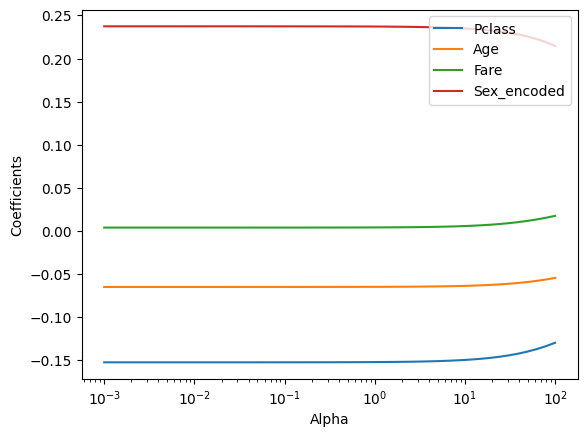

In [23]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(alphas,coef)
ax.set_xscale('log')
ax.set_xlabel("Alpha")
ax.set_ylabel("Coefficients")
ax.legend(features)
plt.show()

In [24]:
#Lasso
lasso_coef=[]
for a in alphas:
  clf_Lasso = Lasso(alpha=a)
  clf_Lasso.fit(X_scaled,y)
  lasso_coef.append(clf_Lasso.coef_)
lasso_coef=np.array(lasso_coef)

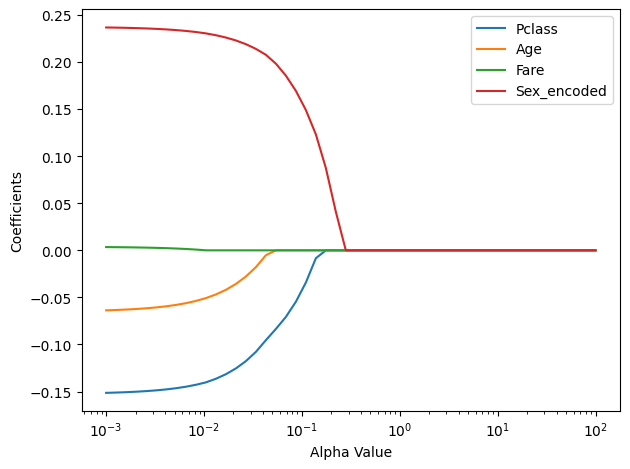

In [25]:
fig, ax = plt.subplots()
ax.plot(alphas,lasso_coef)

ax.set_xlabel("Alpha Value")
ax.set_ylabel("Coefficients")
ax.set_xscale('log')
ax.legend(features)
plt.tight_layout()
plt.show()

## Ridge (L2) v/s Lasso (L1)

1. Multicollinearity - Pclass and Fare are taken as redundant values by Lasso. Hence, Lasso makes fare 0 from the start. Other features start getting towards 0 depending upon the coefficients. Sex_encoded drops to 0 gradually around 0.5.

2. Ridge regularisation - coefficients never reach zero, even for features which may not be very influential like fare.

3. Sex_encoded survives longer before being taken down to zero. This confirms the analysis that gender was the strongest predictor for survival.

## Task 3 — Polynomial features + overfitting:
1. simple 1-feature data.
2. Fit degree 1, 2, 5, 10 using PolynomialFeatures + LinearRegression

In [47]:
from sklearn.datasets import  make_regression
X,y = make_regression(n_samples=50, n_features=1, noise=20, random_state= 42)

In [51]:
X.shape

(50, 1)

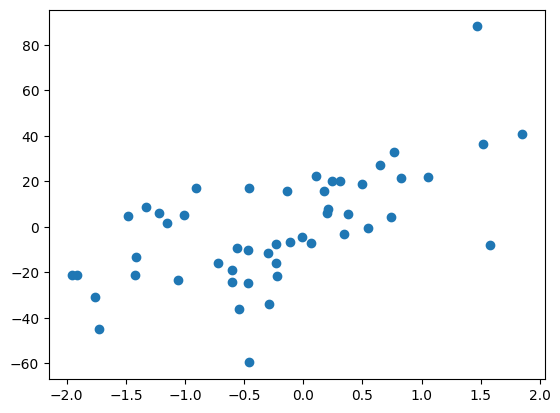

In [50]:
fig,ax = plt.subplots()
ax.scatter(X, y)

plt.show()

In [75]:
from sklearn.preprocessing import  PolynomialFeatures
from sklearn.linear_model import  LinearRegression

polyeFEature = PolynomialFeatures(degree=2).fit_transform(X)
polyeFEature

array([[ 1.00000000e+00, -2.91693750e-01,  8.50852437e-02],
       [ 1.00000000e+00, -1.91328024e+00,  3.66064129e+00],
       [ 1.00000000e+00,  3.14247333e-01,  9.87513860e-02],
       [ 1.00000000e+00,  5.42560044e-01,  2.94371401e-01],
       [ 1.00000000e+00,  1.57921282e+00,  2.49391312e+00],
       [ 1.00000000e+00,  2.41962272e-01,  5.85457409e-02],
       [ 1.00000000e+00,  7.67434729e-01,  5.88956064e-01],
       [ 1.00000000e+00, -1.47852199e+00,  2.18602728e+00],
       [ 1.00000000e+00,  1.96861236e-01,  3.87543462e-02],
       [ 1.00000000e+00, -5.62287529e-01,  3.16167266e-01],
       [ 1.00000000e+00,  1.05712223e+00,  1.11750740e+00],
       [ 1.00000000e+00, -1.15099358e+00,  1.32478622e+00],
       [ 1.00000000e+00, -4.69474386e-01,  2.20406199e-01],
       [ 1.00000000e+00, -6.01706612e-01,  3.62050847e-01],
       [ 1.00000000e+00, -2.25776300e-01,  5.09749379e-02],
       [ 1.00000000e+00,  8.22544912e-01,  6.76580132e-01],
       [ 1.00000000e+00, -1.41230370e+00

In [72]:
polyeFEature.shape

(50, 3)

In [76]:
predictLin = LinearRegression().fit(polyeFEature,y)
predictLin

LinearRegression()

In [84]:
y_pred = predictLin.predict(polyeFEature)
y_pred

array([ -5.4117575 , -19.10908483,   5.69243744,  10.72109226,
        39.3691782 ,   4.19670049,  16.12597697, -17.72502879,
         3.28693977,  -9.31866295,  23.74970691, -15.57509763,
        -8.05177803,  -9.83361094,  -4.36165087,  17.51898476,
       -17.36710276,  -9.81984186,  -4.49724063,  -9.08021322,
       -19.15778054,  -7.96644944,  37.57225728, -14.78869468,
        -4.4969755 ,   1.60336057,  -2.52126184,  35.76591529,
       -16.11342243, -13.36549479,  -0.71801182,   9.67422422,
       -11.29434504,   0.77813343,   7.00043331,   2.78068681,
       -18.82036508, -14.38284439,   3.52728495,  13.19203705,
        -2.90798355, -16.85634406,  -7.99906087,  15.40455693,
         6.31342834,  -7.92719023,  48.50144933, -18.71525899,
       -17.43733596,  -5.55852037])

In [86]:
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_plot

array([[-1.95967012],
       [-1.94692113],
       [-1.93417214],
       [-1.92142315],
       [-1.90867416],
       [-1.89592517],
       [-1.88317618],
       [-1.87042719],
       [-1.8576782 ],
       [-1.8449292 ],
       [-1.83218021],
       [-1.81943122],
       [-1.80668223],
       [-1.79393324],
       [-1.78118425],
       [-1.76843526],
       [-1.75568627],
       [-1.74293728],
       [-1.73018829],
       [-1.71743929],
       [-1.7046903 ],
       [-1.69194131],
       [-1.67919232],
       [-1.66644333],
       [-1.65369434],
       [-1.64094535],
       [-1.62819636],
       [-1.61544737],
       [-1.60269838],
       [-1.58994938],
       [-1.57720039],
       [-1.5644514 ],
       [-1.55170241],
       [-1.53895342],
       [-1.52620443],
       [-1.51345544],
       [-1.50070645],
       [-1.48795746],
       [-1.47520847],
       [-1.46245947],
       [-1.44971048],
       [-1.43696149],
       [-1.4242125 ],
       [-1.41146351],
       [-1.39871452],
       [-1

In [87]:
new_polyFeatures = PolynomialFeatures(degree=2).fit_transform(X_plot)
new_polyFeatures

array([[ 1.00000000e+00, -1.95967012e+00,  3.84030699e+00],
       [ 1.00000000e+00, -1.94692113e+00,  3.79050190e+00],
       [ 1.00000000e+00, -1.93417214e+00,  3.74102187e+00],
       [ 1.00000000e+00, -1.92142315e+00,  3.69186692e+00],
       [ 1.00000000e+00, -1.90867416e+00,  3.64303705e+00],
       [ 1.00000000e+00, -1.89592517e+00,  3.59453225e+00],
       [ 1.00000000e+00, -1.88317618e+00,  3.54635252e+00],
       [ 1.00000000e+00, -1.87042719e+00,  3.49849786e+00],
       [ 1.00000000e+00, -1.85767820e+00,  3.45096828e+00],
       [ 1.00000000e+00, -1.84492920e+00,  3.40376377e+00],
       [ 1.00000000e+00, -1.83218021e+00,  3.35688434e+00],
       [ 1.00000000e+00, -1.81943122e+00,  3.31032997e+00],
       [ 1.00000000e+00, -1.80668223e+00,  3.26410069e+00],
       [ 1.00000000e+00, -1.79393324e+00,  3.21819647e+00],
       [ 1.00000000e+00, -1.78118425e+00,  3.17261733e+00],
       [ 1.00000000e+00, -1.76843526e+00,  3.12736326e+00],
       [ 1.00000000e+00, -1.75568627e+00

In [90]:
New_Lin = LinearRegression().fit(new_polyFeatures,y)


ValueError: Found input variables with inconsistent numbers of samples: [300, 50]

In [88]:
new_predict = new_polyFeatures.predict(new_polyFeatures)

AttributeError: 'numpy.ndarray' object has no attribute 'predict'

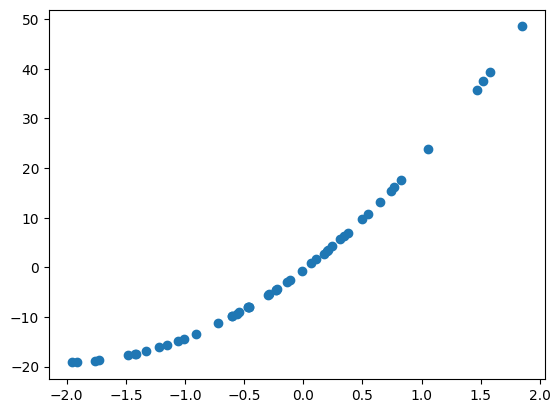

In [83]:
fig,ax = plt.subplots()
ax.scatter(X,y_pred)

plt.show()

In [41]:
#Fit degree 1, 2, 5, 10 using PolynomialFeatures + LinearRegression in a loop
from sklearn.preprocessing import  PolynomialFeatures
from sklearn.linear_model import  LinearRegression
#from sklearn.pipeline import make_pipeline

#model = make_pipeline

poly = PolynomialFeatures(degree=2)
poly_features = poly.fit_transform(X.reshape(-1,1))

#LIN REG
poly_reg_model = LinearRegression()

In [42]:
poly_reg_model.fit(poly_features,y)

LinearRegression()

In [43]:
poly_predict =- poly_reg_model.predict(poly_features)
poly_predict

array([  5.4117575 ,  19.10908483,  -5.69243744, -10.72109226,
       -39.3691782 ,  -4.19670049, -16.12597697,  17.72502879,
        -3.28693977,   9.31866295, -23.74970691,  15.57509763,
         8.05177803,   9.83361094,   4.36165087, -17.51898476,
        17.36710276,   9.81984186,   4.49724063,   9.08021322,
        19.15778054,   7.96644944, -37.57225728,  14.78869468,
         4.4969755 ,  -1.60336057,   2.52126184, -35.76591529,
        16.11342243,  13.36549479,   0.71801182,  -9.67422422,
        11.29434504,  -0.77813343,  -7.00043331,  -2.78068681,
        18.82036508,  14.38284439,  -3.52728495, -13.19203705,
         2.90798355,  16.85634406,   7.99906087, -15.40455693,
        -6.31342834,   7.92719023, -48.50144933,  18.71525899,
        17.43733596,   5.55852037])

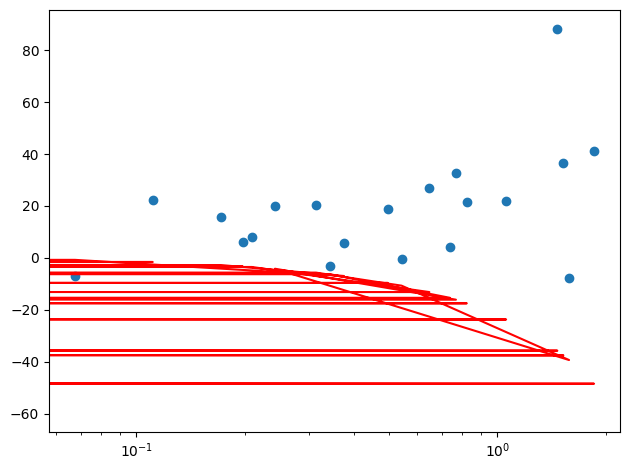

In [64]:


fig, ax = plt.subplots()

ax.scatter(X,y)
ax.plot(X,poly_predict,c="red")
#ax.set_xlabel("Alpha Value")
#ax.set_ylabel("Coefficients")
ax.set_xscale('log')
plt.tight_layout()
plt.show()

In [31]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

X_train = np.array([[2, 4],
                    [6, 8],
                    [10, 12]])

scaler = MinMaxScaler()
scaler.fit(X_train)
scaler.data_max_



array([10., 12.])

In [32]:
X_scaled = scaler.transform(X_train)
print(X_scaled)

[[0.  0. ]
 [0.5 0.5]
 [1.  1. ]]


In [33]:
scaler.fit_transform(X_train)

array([[0. , 0. ],
       [0.5, 0.5],
       [1. , 1. ]])

In [34]:
print(np.min(X_scaled, axis=0))

[0. 0.]


In [35]:
print(np.max(X_scaled, axis=0))

[1. 1.]


In [36]:
class MinMaxScaler():

  def __init__(self):
    self.max_ = None
    self.min_ = None

  def fit(self,X):
    self.max_ = np.max(X,axis=0)
    self.min_ = np.min(X,axis=0)
    return self

  # z = (x - min) / (max - min)
  def transform(self,X):
    X_out = (X - self.min_) / (self.max_ - self.min_)
    return X_out

  def fit_transform(self,X):
    X_out = self.fit(X).transform(X)
    return X_out

X_train = np.array([[2, 4],
                    [6, 8],
                    [10, 12]])

scaler1 = MinMaxScaler()
scaler1.fit(X_train)

print(scaler1.min_)
print(scaler1.max_)

[2 4]
[10 12]


In [37]:
x_scaled1 = scaler1.transform(X_train)
print(x_scaled1)

[[0.  0. ]
 [0.5 0.5]
 [1.  1. ]]


In [38]:
print(np.min(x_scaled1, axis=0))  # should be [0. 0.]
print(np.max(x_scaled1, axis=0))  # should be [1. 1.]

[0. 0.]
[1. 1.]
